# MCMC with INLA: a parameter outside the latent Gaussian model

`inla()` needs the model to be *latent Gaussian*: given the
hyperparameters $\theta$, every effect enters the linear predictor
linearly with a Gaussian prior. Many models are latent Gaussian only
*conditionally* on a few extra parameters $\phi$, such as a distance-decay
length, a change point or a spatial-lag coefficient.

Gómez-Rubio & Rue (2018) combine the two: run MCMC over $\phi$ (here
jointly with $\theta$), and let INLA integrate out the latent field. For
fixed $\phi$ the LGM gives the Laplace approximation of
$\log\pi(y\mid\theta,\phi)$, with exact gradients. So
`model.log_posterior_theta` can be a NumPyro potential, and NUTS
samples $\pi(\phi,\theta\mid y)$ while the latent field never appears in
the chain.

This notebook fits a Poisson model with a non-linear distance effect:

$$
y_i \sim \mathrm{Poisson}(e^{\eta_i}),\qquad
\eta_i = \beta_0 + \beta_1 e^{-d_i/\phi} + u_{g(i)},\qquad
u_g \sim \mathcal N(0, \tau^{-1}).
$$

Given the decay length $\phi$, the covariate $z_i = e^{-d_i/\phi}$ is
fixed and the model is an LGM. Two routes, which should agree:

1. **INLA over a grid of $\phi$**, weighting each fit by its marginal
   likelihood (Bayesian model averaging, BMA).
2. **NUTS over $(\phi, \theta)$**, with `log_posterior_theta` as the
   potential.

In [1]:
import subprocess
import sys


if "google.colab" in sys.modules:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pyrox-lgm", "matplotlib"],
        check=True,
    )

In [2]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pyrox_lgm as lgm
from numpyro.infer import MCMC, NUTS


jax.config.update("jax_enable_x64", True)

/home/user/pyrox-p9c/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

600 counts in 20 groups. Each observation sits at a distance
$d_i \in [0, 6]$ from a source whose effect decays with length
$\phi = 2$.

In [3]:
rng = np.random.default_rng(0)
n_obs, n_groups = 600, 20
truth = {"b0": 0.5, "b1": 1.5, "phi": 2.0, "tau": 4.0}
group = rng.integers(0, n_groups, n_obs)
d = rng.uniform(0.0, 6.0, n_obs)
u = rng.normal(0.0, truth["tau"] ** -0.5, n_groups)
eta = truth["b0"] + truth["b1"] * np.exp(-d / truth["phi"]) + u[group]
y = rng.poisson(np.exp(eta)).astype(float)

model = lgm.LGM(
    components=(lgm.IID(n_groups, name="g"),),
    fixed=lgm.FixedEffects(("intercept", "z")),
    likelihood=lgm.Poisson(),
)


def data_at(phi):
    """The LGM's data for a decay length phi (a JAX value, so it can be traced)."""
    return {"y": y, "g": group, "z": jnp.exp(-jnp.asarray(d) / phi)}

## Route 1: INLA on a grid of $\phi$

Each fit returns $\log\tilde\pi(y\mid\phi)$. With a log-normal prior on
$\phi$, the posterior on the grid is proportional to
$\tilde\pi(y\mid\phi)\,\pi(\phi)$, and averaging the fits with those
weights gives every other marginal.

In [4]:
phi_prior = dist.LogNormal(jnp.log(3.0), 0.75)
grid = np.exp(np.linspace(np.log(0.5), np.log(8.0), 33))
t0 = time.perf_counter()
fits = [lgm.inla(model, data_at(p)) for p in grid]
print(f"{len(grid)} INLA fits in {time.perf_counter() - t0:.1f} s")
log_post = np.array([float(f.log_marginal_likelihood) for f in fits]) + np.asarray(
    phi_prior.log_prob(jnp.asarray(grid))
)
# Weights for an integral over log(phi) on the uniform log grid (Jacobian phi).
log_w = log_post + np.log(grid)
bma = np.exp(log_w - log_w.max())
bma /= bma.sum()
phi_mean_grid = float(np.sum(bma * grid))
print(f"E[phi | y] by INLA + BMA: {phi_mean_grid:.3f}")

33 INLA fits in 64.5 s


E[phi | y] by INLA + BMA: 2.784


## Route 2: NUTS over $(\phi, \theta)$ with the INLA potential

`log_posterior_theta(u, data)` is $\log\tilde\pi(y\mid\theta,\phi) +
\log\pi(u)$ in the unconstrained hyperparameters $u$. That includes their
prior and Jacobian, so $u$ takes an improper flat site and the potential
adds the rest. The projector is rebuilt inside the model, because its
$z$ column depends on $\phi$; its pattern does not, so gaussx reuses one
symbolic Cholesky.

In [5]:
def hybrid():
    phi = numpyro.sample("phi", phi_prior)
    u = numpyro.sample(
        "u", dist.ImproperUniform(dist.constraints.real_vector, (), (model.n_theta,))
    )
    numpyro.factor("lgm", model.log_posterior_theta(u, data_at(phi)))


mcmc = MCMC(NUTS(hybrid), num_warmup=500, num_samples=1000, progress_bar=False)
t0 = time.perf_counter()
mcmc.run(jax.random.key(1), init_params={"phi": jnp.array(3.0), "u": jnp.zeros(1)})
print(f"NUTS in {time.perf_counter() - t0:.1f} s")
samples = mcmc.get_samples()
mcmc.print_summary()

NUTS in 16.4 s



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       phi      2.81      0.75      2.66      1.78      3.78    566.14      1.00
      u[0]      1.87      0.35      1.88      1.31      2.45    437.45      1.00

Number of divergences: 0


The chain's $u$ is $\log\tau$: `unflatten` maps it back to $\tau$.

In [6]:
tau_draws = np.asarray(jax.vmap(lambda v: model.unflatten(v)["g.tau"])(samples["u"]))
phi_draws = np.asarray(samples["phi"])
print(f"E[phi | y] by NUTS:       {phi_draws.mean():.3f}")
print(f"E[tau | y] by NUTS:       {tau_draws.mean():.3f}")
tau_grid = np.sum(bma * np.array([float(f.hyperpar["g.tau"].mean) for f in fits]))
print(f"E[tau | y] by INLA + BMA: {tau_grid:.3f}")

E[phi | y] by NUTS:       2.812
E[tau | y] by NUTS:       6.862
E[tau | y] by INLA + BMA: 7.075


## The two routes agree

Left: the posterior of $\phi$, from NUTS (histogram) and from the INLA
grid (curve, normalised as a density in $\phi$). Right: the slope
$\beta_1$ of the distance effect from the BMA over the grid. Each fit's
Gaussian marginal is weighted by $\pi(\phi\mid y)$. A longer decay with a
larger slope fits these data almost as well, so the two posteriors lean
the same way, and the mixture over $\phi$ makes $\beta_1$'s marginal skewed
where any single fit's is Gaussian.

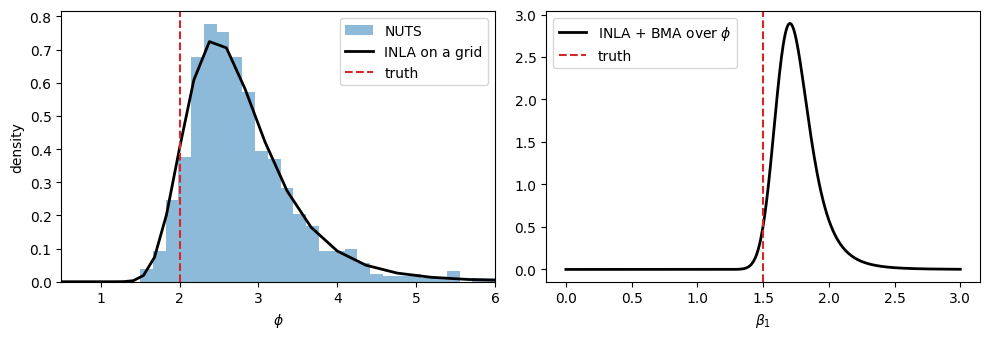

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
ax = axes[0]
ax.hist(phi_draws, bins=40, density=True, alpha=0.5, label="NUTS")
dens = bma / np.log(grid[1] / grid[0]) / grid  # mass per log-step -> density in phi
ax.plot(grid, dens, "k-", lw=2, label="INLA on a grid")
ax.axvline(truth["phi"], color="C3", ls="--", label="truth")
ax.set_xlabel(r"$\phi$")
ax.set_ylabel("density")
ax.set_xlim(0.5, 6.0)
ax.legend()

ax = axes[1]
b = np.linspace(0.0, 3.0, 400)
mix = sum(
    w
    * np.exp(-0.5 * ((b - float(f.fixed["z"].mean)) / float(f.fixed["z"].sd)) ** 2)
    / (np.sqrt(2 * np.pi) * float(f.fixed["z"].sd))
    for w, f in zip(bma, fits, strict=True)
)
ax.plot(b, mix, "k-", lw=2, label=r"INLA + BMA over $\phi$")
ax.axvline(truth["b1"], color="C3", ls="--", label="truth")
ax.set_xlabel(r"$\beta_1$")
ax.legend()
fig.tight_layout()
plt.show()

## When to use which

- **The grid** is cheap and deterministic for one or two extra parameters,
  and it gives the marginal likelihood of each.
- **NUTS** scales to several extra parameters, where a grid cannot, and
  samples $\phi$ jointly with $\theta$. Each step runs a Laplace fit, so a
  chain costs about as many fits as it takes leapfrog steps.

For latent effects under NUTS, refit at a thinned set of draws
(`model.laplace(u, data_at(phi))`) and mix the Gaussian marginals, as
the grid route does with its weights.

**Reference.** Gómez-Rubio, V. & Rue, H. (2018). Markov chain Monte Carlo
with the integrated nested Laplace approximation. *Statistics and
Computing* 28, 1033–1051.